# Single Neuron Regression Analysis :)

In [240]:
import os
%load_ext autoreload
%autoreload 2
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import umap
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [259]:
significant_results = pd.read_pickle('/home/connorlab/Documents/GitHub/Julie/Cortana/analysis_results/directional_linear_regression_on_single_neurons_low_variance_removed.pkl')
significant_results = significant_results[significant_results['p_value'] < 0.05]
print(significant_results.shape)
print(significant_results['NeuronID'].nunique())

(2768, 7)
821


In [242]:
significant_results.head()

,NeuronID,Behavior,Source_Monkey,Model,R-squared,coef,p_value
15080,2023-12-11_4_Channel.C_030,AffliationFrom,110E,ols,0.499564,14.789924,0.049970
6691,2023-12-07_2_Channel.C_012,AffliationTo,94B,ols,0.499564,-3.224724,0.049970
39957,2023-12-18_1_Channel.C_029_Unit 1,AgonismTo,143H,ols,0.499632,0.793089,0.049947
24466,2023-09-26_1_Channel.C_019,SubmissionFrom,110E,ols,0.499646,0.261939,0.049943
9996,2023-10-04_2_Channel.C_013,AffliationFrom,7124,ols,0.499718,-28.856521,0.049919


## Simple Visualization

### Bar Plot

In [180]:
from analyses.linear_regression.run_single_neuron_regressions import plot_single_neuron_profile
#
# for neuron_id in significant_results['NeuronID'].unique():
#     plot_single_neuron_profile(significant_results, neuron_id)

### Count Plot

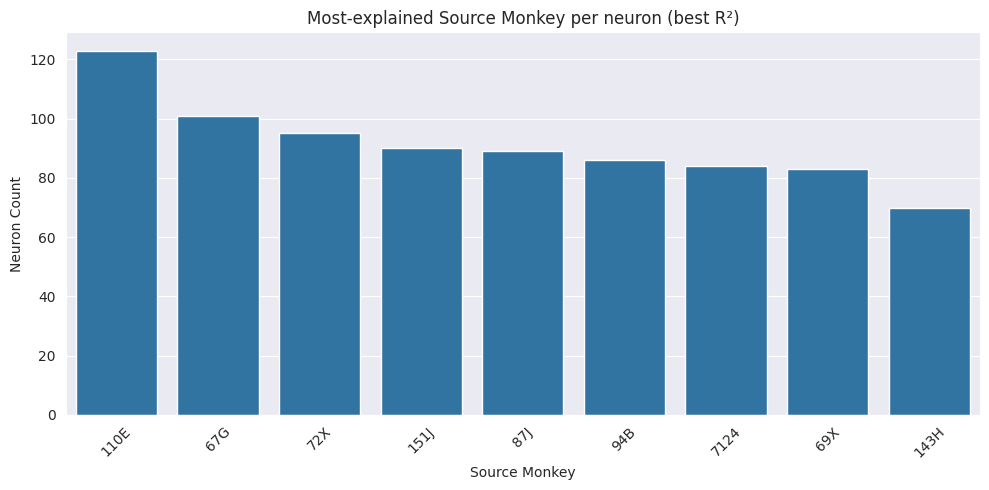

In [243]:
best_monkey_df = significant_results.sort_values('R-squared', ascending=False).drop_duplicates('NeuronID')
plt.figure(figsize=(10, 5))
sns.countplot(data=best_monkey_df, x='Source_Monkey', order=best_monkey_df['Source_Monkey'].value_counts().index)
plt.title("Most-explained Source Monkey per neuron (best R²)")
plt.xlabel("Source Monkey")
plt.ylabel("Neuron Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Distribution of Coefficients

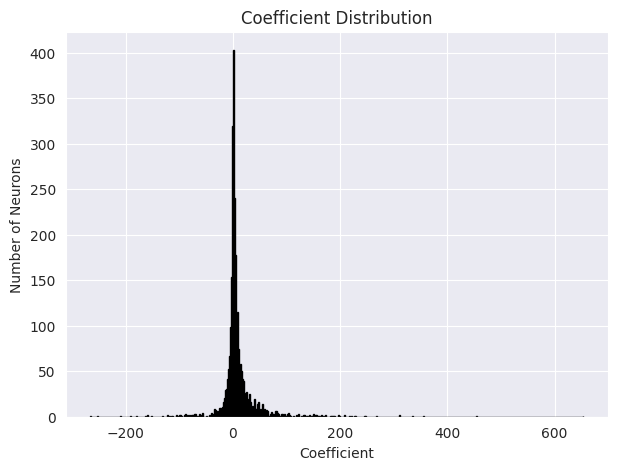

In [244]:
# Coefficient distribution
plt.figure(figsize=(7, 5))
plt.hist(significant_results['coef'], bins=500, edgecolor='black')
plt.title('Coefficient Distribution')
plt.xlabel('Coefficient')
plt.ylabel('Number of Neurons')
plt.grid(True)
plt.show()

### Distribution of R-squared values

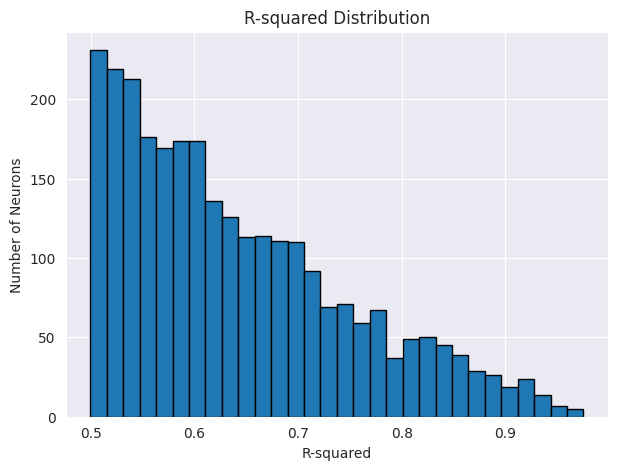

In [245]:
# R-squared distribution
plt.figure(figsize=(7, 5))
plt.hist(significant_results['R-squared'].dropna(), bins=30, edgecolor='black')  # dropna() just in case
plt.title('R-squared Distribution')
plt.xlabel('R-squared')
plt.ylabel('Number of Neurons')
plt.grid(True)
plt.show()

## Boxplot Behavior

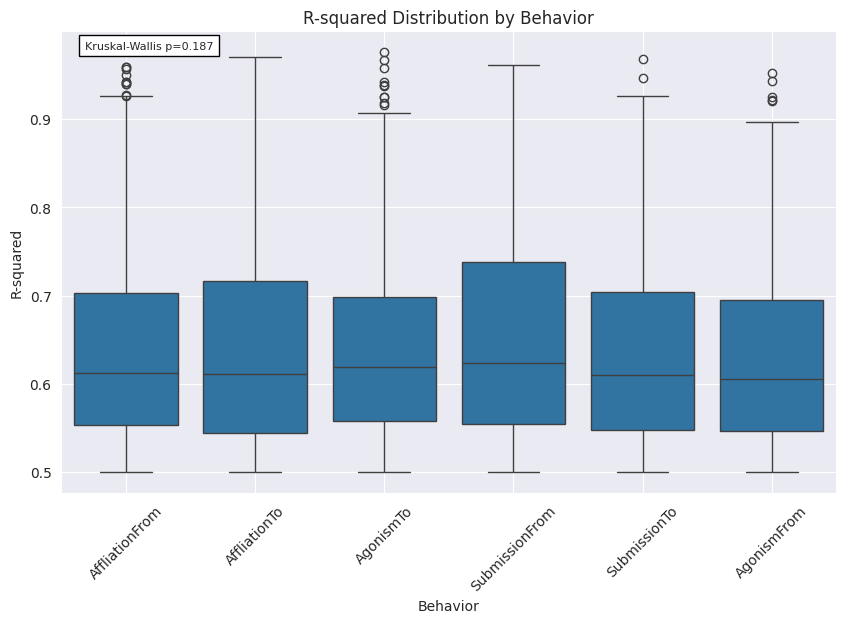

In [246]:
# Box Plot
from scipy.stats import kruskal

# 1. Kruskal-Wallis Test (behavior)
groups = [group['R-squared'].values for name, group in significant_results.groupby('Behavior')]
stat, p = kruskal(*groups)

# 2. Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='Behavior',
    y='R-squared',
    data=significant_results,
)
plt.title('R-squared Distribution by Behavior')
plt.xlabel('Behavior')
plt.ylabel('R-squared')
plt.xticks(rotation=45)
plt.grid(True)

# 3. Add text with p-value
plt.text(
    0.03, 0.98,
    f'Kruskal-Wallis p={p:.3f}',
    horizontalalignment='left',
    verticalalignment='top',
    transform=plt.gca().transAxes,
    fontsize=8,
    bbox=dict(facecolor='white', edgecolor='black')
)

plt.show()

In [248]:
plt.show()
import scikit_posthocs as sp

# Dunn's test (with Bonferroni correction)
dunn_results = sp.posthoc_dunn(
    significant_results,
    val_col='R-squared',
    group_col='Behavior',
    p_adjust='bonferroni'  # multiple comparisons correction
)

# Show matrix
dunn_results

,AffliationFrom,AffliationTo,AgonismFrom,AgonismTo,SubmissionFrom,SubmissionTo
AffliationFrom,1.0,1.0,1.000000,1.0,1.000000,1.000000
AffliationTo,1.0,1.0,1.000000,1.0,1.000000,1.000000
AgonismFrom,1.0,1.0,1.000000,1.0,0.229825,1.000000
AgonismTo,1.0,1.0,1.000000,1.0,1.000000,1.000000
SubmissionFrom,1.0,1.0,0.229825,1.0,1.000000,0.409198
SubmissionTo,1.0,1.0,1.000000,1.0,0.409198,1.000000


Seems like only AgonismFrom vs SubmissionFrom are significantly different

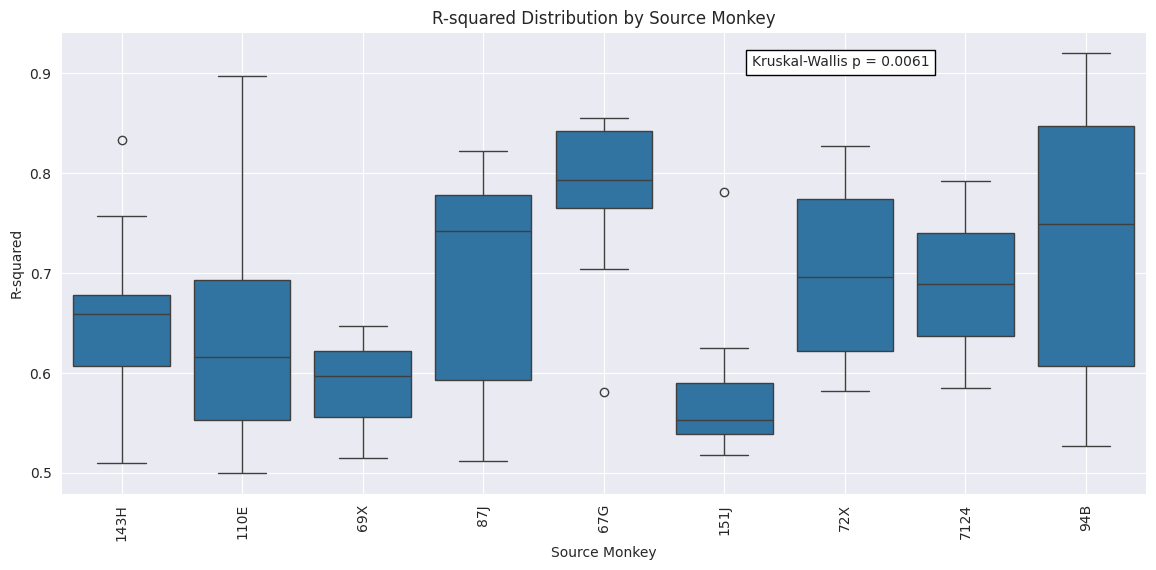

In [186]:
# 1. Kruskal-Wallis Test (Source_Monkey 기준)
groups = [group['R-squared'].values for name, group in significant_results.groupby('Source_Monkey')]
stat, p = kruskal(*groups)

# 2. Boxplot
plt.figure(figsize=(14, 6))  # Monkey가 많으니까 width 넓힘
sns.boxplot(
    x='Source_Monkey',
    y='R-squared',
    data=significant_results,
)
plt.title('R-squared Distribution by Source Monkey')
plt.xlabel('Source Monkey')
plt.ylabel('R-squared')
plt.xticks(rotation=90)
plt.grid(True)

# 3. Add p-value to upper right corner
plt.text(
    0.80, 0.95,
    f'Kruskal-Wallis p = {p:.4f}',
    horizontalalignment='right',
    verticalalignment='top',
    transform=plt.gca().transAxes,
    fontsize=10,
    bbox=dict(facecolor='white', edgecolor='black')
)

plt.show()

In [249]:
import scikit_posthocs as sp
import pandas as pd

# Dunn's test (with Bonferroni correction)
dunn_results = sp.posthoc_dunn(
    significant_results,
    val_col='R-squared',
    group_col='Source_Monkey',
    p_adjust='bonferroni'  # multiple comparisons correction
)

# Show matrix
dunn_results

,110E,143H,151J,67G,69X,7124,72X,87J,94B
110E,1.000000,0.910349,1.0,0.541662,1.000000,1.000000,1.0,1.000000,1.000000
143H,0.910349,1.000000,1.0,1.000000,0.077498,1.000000,1.0,1.000000,1.000000
151J,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.0,1.000000,1.000000
67G,0.541662,1.000000,1.0,1.000000,0.037943,0.903401,1.0,1.000000,1.000000
69X,1.000000,0.077498,1.0,0.037943,1.000000,1.000000,1.0,0.549907,0.187578
7124,1.000000,1.000000,1.0,0.903401,1.000000,1.000000,1.0,1.000000,1.000000
72X,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.0,1.000000,1.000000
87J,1.000000,1.000000,1.0,1.000000,0.549907,1.000000,1.0,1.000000,1.000000
94B,1.000000,1.000000,1.0,1.000000,0.187578,1.000000,1.0,1.000000,1.000000


Seems like 110E vs 67G, 151J vs 67G have significantly different R-sq values

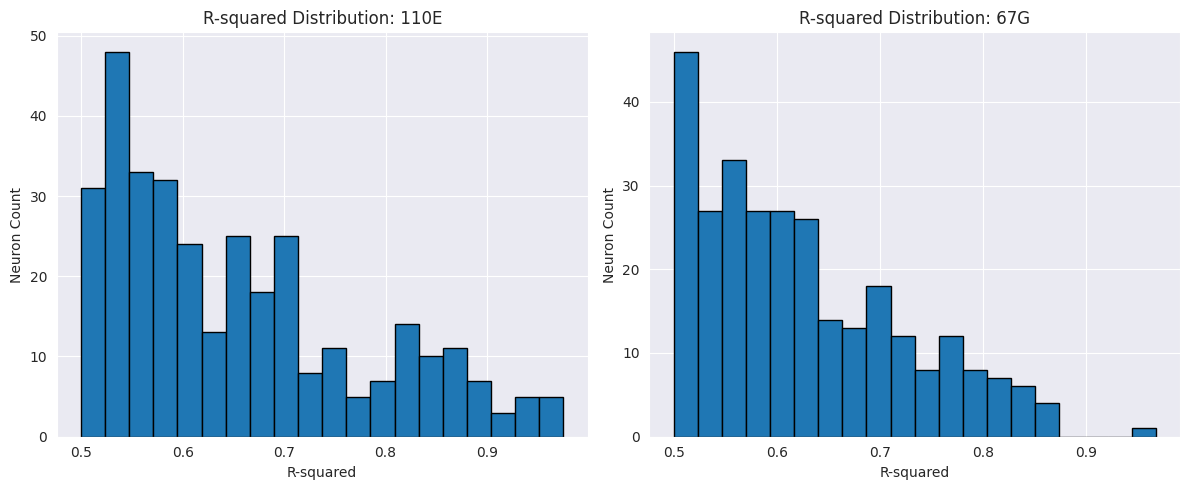

In [250]:
# Comparing R-sq distribution of 67G vs 110E
# filter 110E vs 67G
filtered = significant_results[significant_results['Source_Monkey'].isin(['110E', '67G'])]

r2_110E = filtered[filtered['Source_Monkey'] == '110E']['R-squared']
r2_67G = filtered[filtered['Source_Monkey'] == '67G']['R-squared']

# 플롯
plt.figure(figsize=(12, 5))

# Histogram for 110E
plt.subplot(1, 2, 1)
plt.hist(r2_110E, bins=20, edgecolor='black')
plt.title('R-squared Distribution: 110E')
plt.xlabel('R-squared')
plt.ylabel('Neuron Count')
plt.grid(True)

# Histogram for 67G
plt.subplot(1, 2, 2)
plt.hist(r2_67G, bins=20, edgecolor='black')
plt.title('R-squared Distribution: 67G')
plt.xlabel('R-squared')
plt.ylabel('Neuron Count')
plt.grid(True)

plt.tight_layout()
plt.show()

Comparing one monkey vs rest of the monkeys for R-squared values (is one monkey's R-squared values significantly different from others?)

In [251]:
from scipy.stats import mannwhitneyu
# 67G vs Others
r2_110E = significant_results[significant_results['Source_Monkey'] == '67G']['R-squared']
r2_rest = significant_results[significant_results['Source_Monkey'] != '67G']['R-squared']

# Mann-Whitney U Test
stat, p_value = mannwhitneyu(r2_110E, r2_rest, alternative='two-sided')
print(f'One-vs-Rest Mann-Whitney U-test p-value: {p_value:.4f}')
# significant: 67G, 151J
# not significant: 69X, 72X, 7124, 94B, 110E, 143H, 87J

One-vs-Rest Mann-Whitney U-test p-value: 0.0307


Each of 67G and 151J are significantly different from the rest of the group!

More rigorous -- permutation test! How does 67G different from rest of the monkeys?

In [252]:
# prepare data
r2_67G = significant_results[significant_results['Source_Monkey'] == '67G']['R-squared'].values
r2_rest = significant_results[significant_results['Source_Monkey'] != '67G']['R-squared'].values

# an observed difference between the means
observed_diff = np.mean(r2_67G) - np.mean(r2_rest)

# Permutation test
combined = np.concatenate([r2_67G, r2_rest])
n_permutations = 10000
permuted_diffs = np.zeros(n_permutations)

for i in range(n_permutations):
    np.random.shuffle(combined)
    permuted_67G = combined[:len(r2_67G)]
    permuted_rest = combined[len(r2_67G):]
    permuted_diffs[i] = np.mean(permuted_67G) - np.mean(permuted_rest)

p_value = np.mean(np.abs(permuted_diffs) >= np.abs(observed_diff))

print(f'Observed difference: {observed_diff:.4f}')
print(f'Permutation p-value: {p_value:.4f}')

Observed difference: -0.0174
Permutation p-value: 0.0105


Do the same thing for 151J! How does 67G different from rest of the monkeys?

In [253]:
# prepare data
r2_151J = significant_results[significant_results['Source_Monkey'] == '151J']['R-squared'].values
r2_rest = significant_results[significant_results['Source_Monkey'] != '151J']['R-squared'].values

# an observed difference between the means
observed_diff = np.mean(r2_151J) - np.mean(r2_rest)

# Permutation test
combined = np.concatenate([r2_151J, r2_rest])
n_permutations = 10000
permuted_diffs = np.zeros(n_permutations)

for i in range(n_permutations):
    np.random.shuffle(combined)
    permuted_151J = combined[:len(r2_151J)]
    permuted_rest = combined[len(r2_151J):]
    permuted_diffs[i] = np.mean(permuted_151J) - np.mean(permuted_rest)

p_value = np.mean(np.abs(permuted_diffs) >= np.abs(observed_diff))

print(f'Observed difference: {observed_diff:.4f}')
print(f'Permutation p-value: {p_value:.4f}')

Observed difference: 0.0017
Permutation p-value: 0.8049


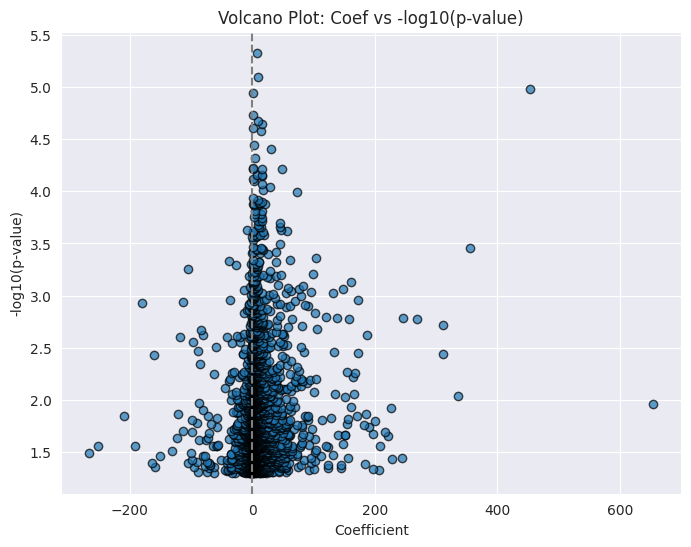

In [254]:
significant_results['neg_log10_p'] = -np.log10(significant_results['p_value'])

plt.figure(figsize=(8,6))
plt.scatter(
    significant_results['coef'],
    significant_results['neg_log10_p'],
    alpha=0.7,
    edgecolors='k'
)
plt.title('Volcano Plot: Coef vs -log10(p-value)')
plt.xlabel('Coefficient')
plt.ylabel('-log10(p-value)')
plt.grid(True)
plt.axvline(x=0, color='gray', linestyle='--')  # 0 기준선
plt.show()

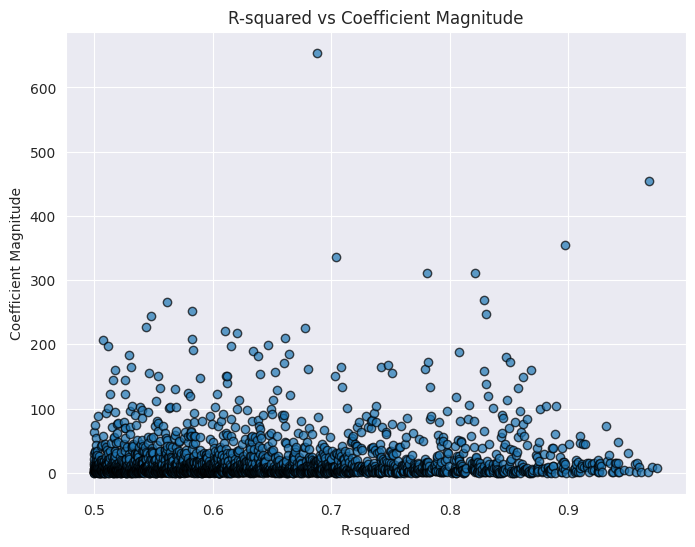

In [255]:
filtered = significant_results[np.abs(significant_results['coef']) < 100]
plt.figure(figsize=(8,6))
plt.scatter(
    significant_results['R-squared'],
    np.abs(significant_results['coef']) ,  # Coef magnitude (절댓값)
    alpha=0.7,
    edgecolors='k'
)
plt.title('R-squared vs Coefficient Magnitude')
plt.xlabel('R-squared')
plt.ylabel('Coefficient Magnitude')
plt.grid(True)
plt.show()

# Representing each neuron as 54-dimensional vector
6 behaviors x 9 source monkeys
(not all of these r-squared values would be p-value with < 0.05 (so they probably didn't pass the filtering) so they would just be 0 here)

In [256]:
# Step 1: 먼저 전체 significant result를 behavior × source_monkey 조합으로 정리
filtered_df = significant_results.sort_values('R-squared', ascending=False)
# Step 2: pivot (NeuronID × [Behavior|SourceMonkey] 조합 → column 이름을 합쳐서 사용)
filtered_df['Behavior_Source'] = filtered_df['Behavior'] + '__' + filtered_df['Source_Monkey']
filtered_df['NeuronID'].nunique()

821

In [257]:
pivot_df = filtered_df.pivot(index='NeuronID', columns='Behavior_Source', values='R-squared').fillna(0)

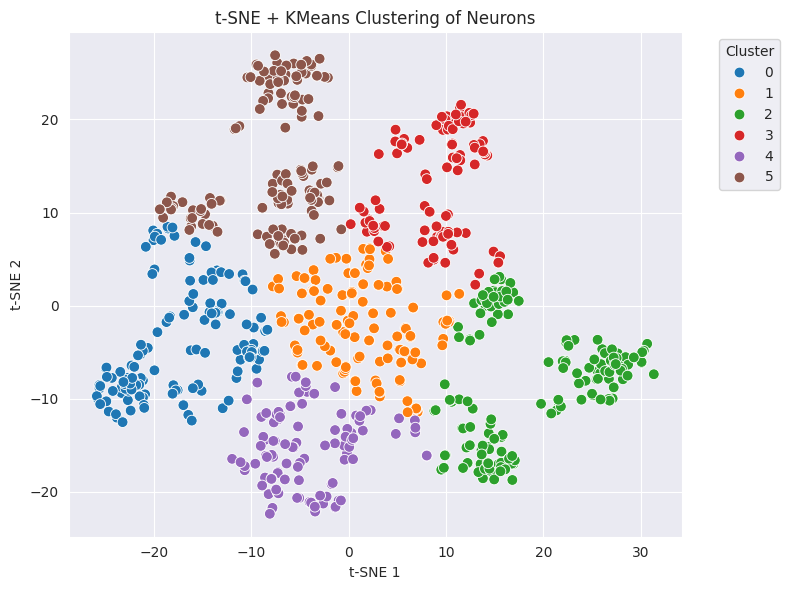

In [263]:
# Scaling
# scaler = StandardScaler()
# scaled_data = scaler.fit_transform(pivot_df)

# t-sne
tsne = TSNE(n_components=2, perplexity=50, random_state=42, init='pca')
tsne_coords = tsne.fit_transform(pivot_df)

# KMeans clustering
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(tsne_coords)

# add cluster colors to t-sne plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=tsne_coords[:, 0], y=tsne_coords[:, 1], hue=cluster_labels, palette='tab10', s=60)
plt.title("t-SNE + KMeans Clustering of Neurons")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


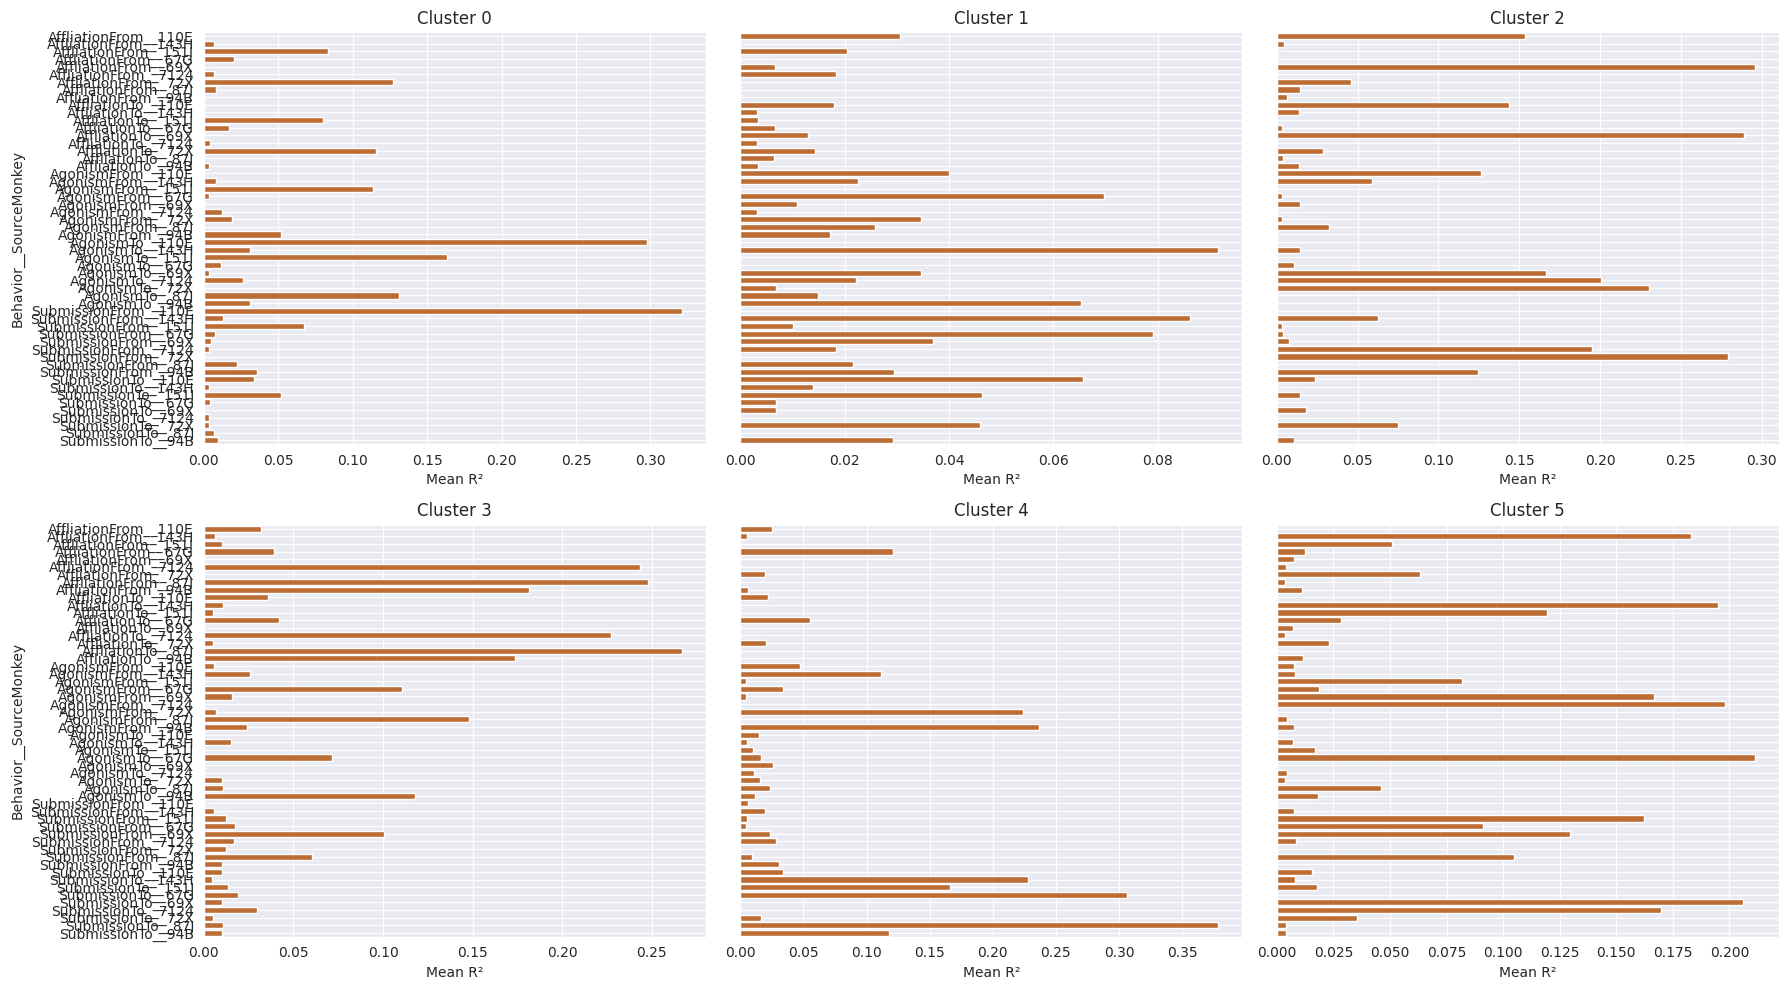

In [264]:
# %matplotlib tk
# pivot_df: NeuronID × Behavior_Source
pivot_df_clustered = pivot_df.copy()
pivot_df_clustered['Cluster'] = cluster_labels

n_clusters = pivot_df_clustered['Cluster'].nunique()

ncols = 3
nrows = (n_clusters + ncols - 1) // ncols  # 자동 계산

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), sharey=True)

axes = axes.flatten()

for i, cluster_id in enumerate(sorted(pivot_df_clustered['Cluster'].unique())):
    ax = axes[i]

    cluster_df = pivot_df_clustered[pivot_df_clustered['Cluster'] == cluster_id].drop(columns='Cluster')
    mean_r2 = cluster_df.mean()
    mean_r2 = mean_r2.sort_index(ascending=True)

    sns.barplot(x=mean_r2.values, y=mean_r2.index, ax=ax, color='chocolate')
    ax.set_title(f"Cluster {cluster_id}")
    ax.set_xlabel("Mean R²")
    if i % ncols == 0:
        ax.set_ylabel("Behavior__SourceMonkey")
    else:
        ax.set_ylabel("")
    ax.grid(True)

# delete remaining empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

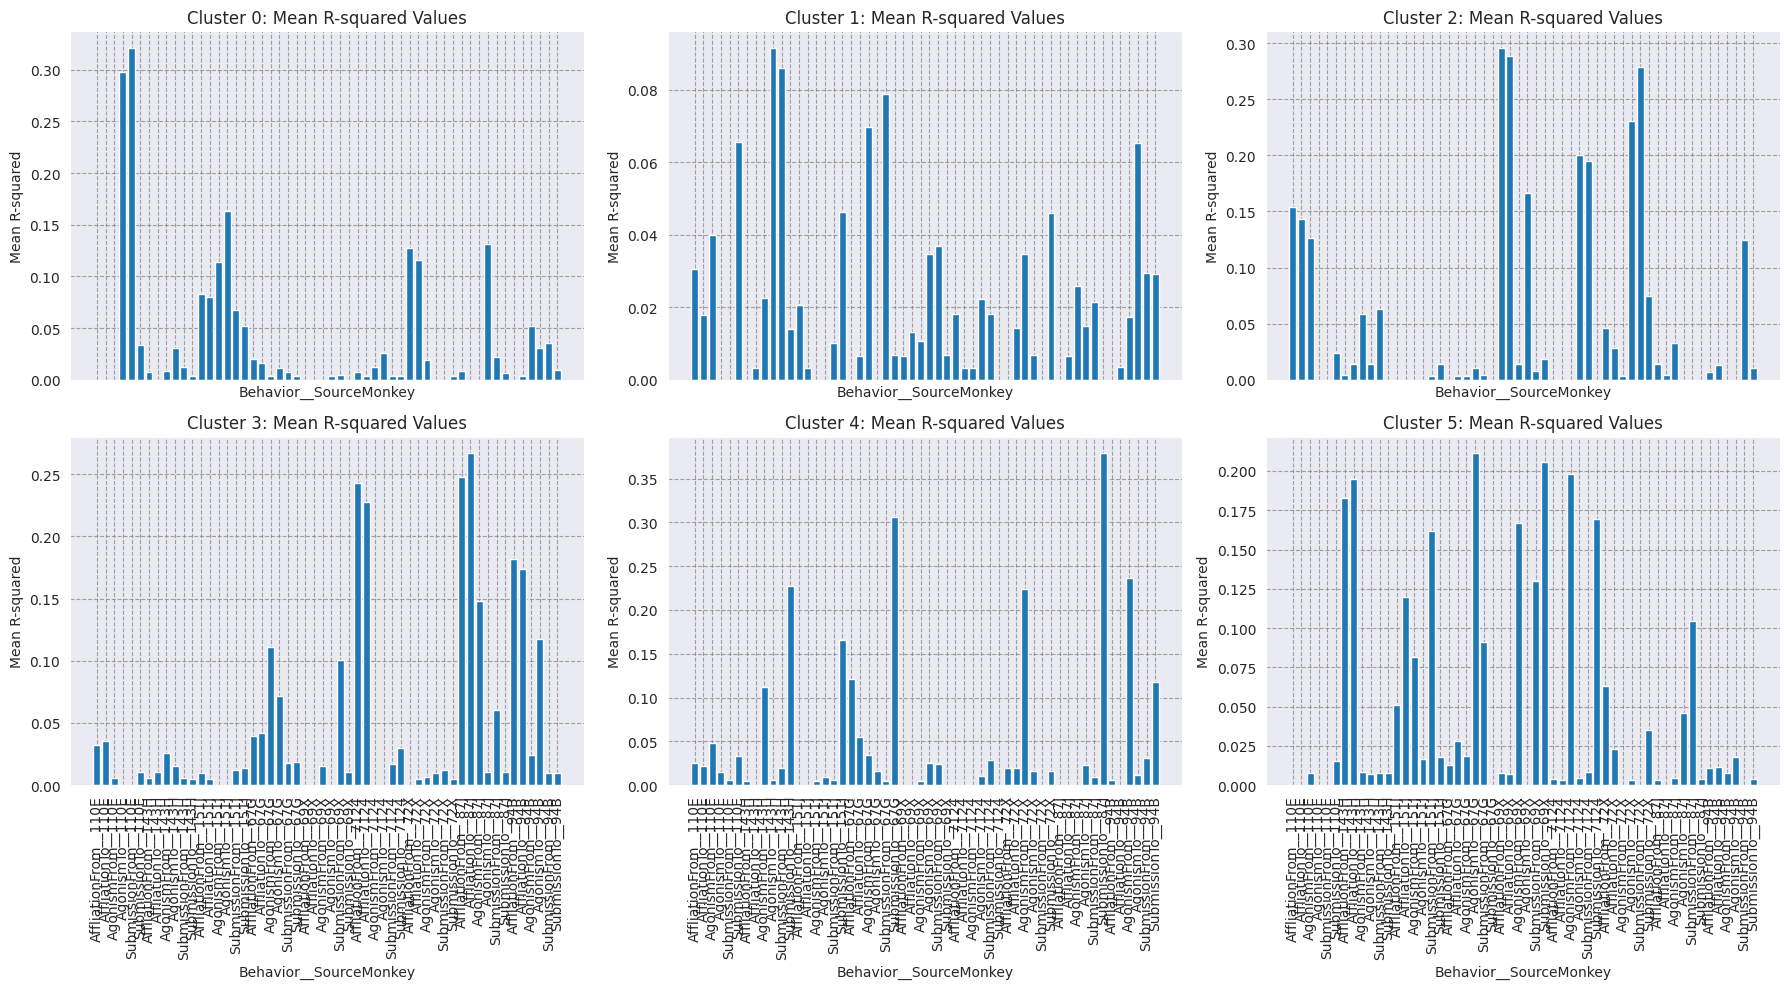

In [265]:
# %matplotlib tk
# Step 1: pivot_df에 cluster label 붙이기
pivot_df_clustered = pivot_df.copy()
pivot_df_clustered['Cluster'] = cluster_labels

# Step 2: Cluster별로 평균 R-squared 값 계산
mean_r2_by_cluster = pivot_df_clustered.groupby('Cluster').mean()

# Step 3: Column 정렬 순서 정의
col_split = mean_r2_by_cluster.columns.str.split('__', expand=True)
col_split_df = pd.DataFrame(col_split.tolist(), columns=['Behavior', 'SourceMonkey'])
sorted_columns = col_split_df.sort_values(['SourceMonkey', 'Behavior']).apply(lambda x: f"{x['Behavior']}__{x['SourceMonkey']}", axis=1)

# Step 4: sort columns
mean_r2_by_cluster = mean_r2_by_cluster[sorted_columns]

n_clusters = mean_r2_by_cluster.shape[0]
ncols = 3
nrows = (n_clusters + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*6, nrows*5), sharex=True)

axes = axes.flatten()

for i, cluster_id in enumerate(sorted(mean_r2_by_cluster.index)):
    ax = axes[i]
    ax.bar(mean_r2_by_cluster.columns, mean_r2_by_cluster.loc[cluster_id])
    ax.set_title(f"Cluster {cluster_id}: Mean R-squared Values", fontsize=12)
    ax.set_ylabel("Mean R-squared", fontsize=10)
    ax.set_xlabel("Behavior__SourceMonkey", fontsize=10)
    ax.tick_params(axis='x', rotation=90)
    ax.grid(True, axis='both', linestyle='--', color='gray', alpha=0.7)

# remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Source Monkey Centered vectorization (9-dim)

In [266]:
%reset
%matplotlib inline
significant_results = pd.read_pickle('/home/connorlab/Documents/GitHub/Julie/Cortana/analysis_results/directional_linear_regression_on_single_neurons_low_variance_removed.pkl')
significant_results = significant_results[significant_results['p_value'] < 0.05]

Nothing done.


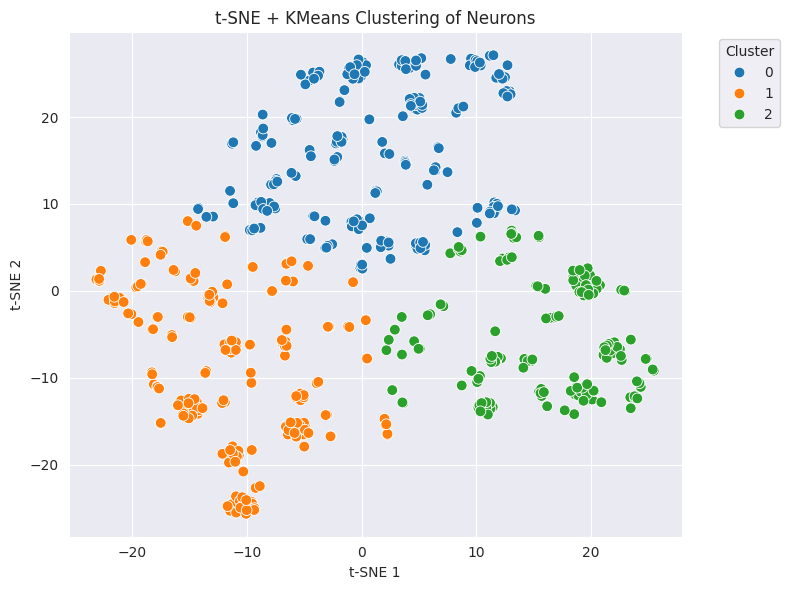

In [275]:
filtered_df = (
        significant_results
        .sort_values('R-squared', ascending=False)
        .drop_duplicates(['NeuronID', 'Source_Monkey'])
    )
filtered_df = filtered_df.reset_index(drop=True)
# Step 1: pivot (NeuronID × SourceMonkey) wide format....
pivot_df = filtered_df.pivot(index='NeuronID', columns='Source_Monkey', values='R-squared').fillna(0)

# pivot_df[pivot_df < 0.05] = 0
pivot_df = pivot_df[(pivot_df > 0).sum(axis=1) >= 2]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(pivot_df)
# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
tsne_coords = tsne.fit_transform(scaled_data)

# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=40, n_init=5)
cluster_labels = kmeans.fit_predict(tsne_coords)

# add cluster colors to t-sne plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=tsne_coords[:, 0], y=tsne_coords[:, 1], hue=cluster_labels, palette='tab10', s=60)
plt.title("t-SNE + KMeans Clustering of Neurons")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

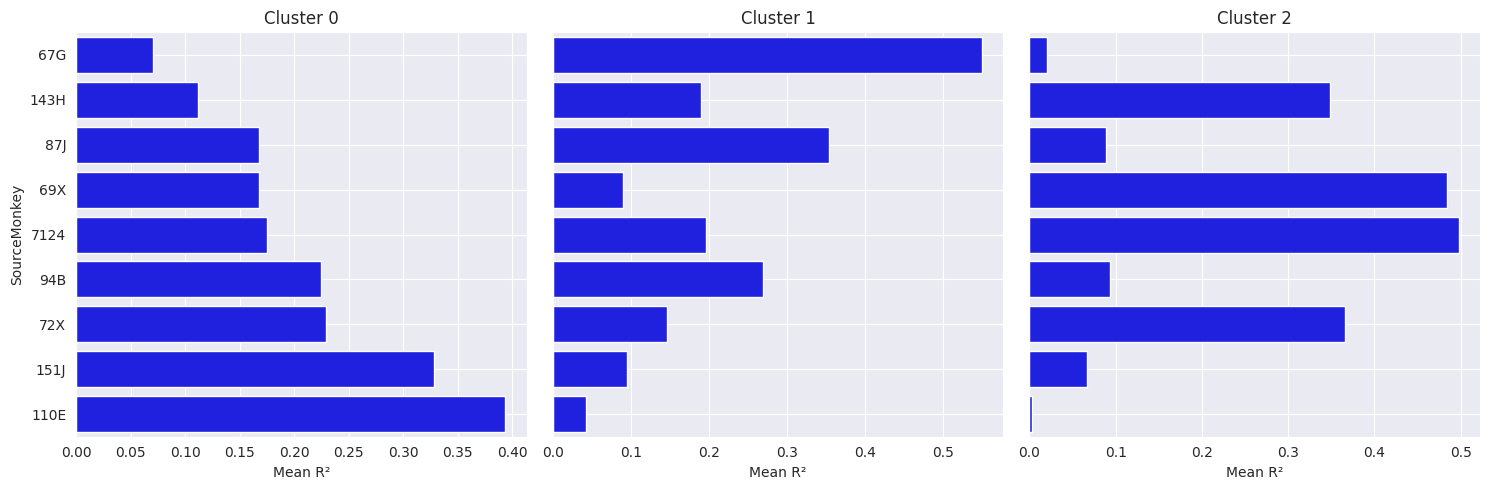

In [276]:
cluster_series = pd.Series(cluster_labels)
pivot_df_clustered = pivot_df.copy()
pivot_df_clustered['Cluster'] = cluster_labels
n_clusters = cluster_series.nunique()
# Figure setup
fig, axes = plt.subplots(1, n_clusters, figsize=(5 * n_clusters, 5), sharey=True)

for i, cluster_id in enumerate(sorted(cluster_series.unique())):
    ax = axes[i] if n_clusters > 1 else axes

    cluster_df = pivot_df_clustered[pivot_df_clustered['Cluster'] == cluster_id].drop(columns='Cluster')
    mean_r2 = cluster_df.mean().sort_values(ascending=True)

    sns.barplot(x=mean_r2.values, y=mean_r2.index, ax=ax, color='blue')
    ax.set_title(f"Cluster {cluster_id}")
    ax.set_xlabel("Mean R²")
    if i == 0:
        ax.set_ylabel("SourceMonkey")
    else:
        ax.set_ylabel("")
    ax.grid(True)

plt.tight_layout()
plt.show()